## Supplementary Figures

**Paper: Countering Local Overfitting for Equitable Spatiotemporal Modeling**

*Zhehao Liang, Stefano Castruccio, Paola Crippa*

This notebook generates all supplementary/appendix figures.


In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Local utilities
import sys
sys.path.append('.')
from source_code import *



# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl
import xarray as xr
import geopandas as gpd


%load_ext autoreload
%autoreload 2

# Setup figure style
#setup_figure_style()

# Define paths
DATA_DIR = "data"
FIGURE_DIR = "Figure"



## Appendix: Ensemble

In [4]:
from source_code.apx_strategy_ab import strategy_ablation_table
from source_code.apx_strategy_ab import estimate_training_cost

cost, timing = estimate_training_cost(
    data_path=r"D:\OneDrive\Code\Ozone_Reconstruction\data\training\Site_Observation_with_feature.pkl",
    nn_epochs=200,
    load_cache=True,
)

fig, latex, raw = strategy_ablation_table(
    f"{DATA_DIR}/appendix/10-Fold-ablation",
    early_stop=False,
    cost_dict=cost,
)

,Site R²,Site RMSE,Region R²,Region RMSE,Spatiotemporal R²,Spatiotemporal RMSE
Model,,,,,,
Ensemble(DLs+MLs)_avg,0.6227 ± 0.0256,9.47 ± 0.35,0.5908 ± 0.0849,9.70 ± 1.35,0.5223 ± 0.0771,10.37 ± 1.18
Ensemble(DL+ML)_avg,0.6071 ± 0.0266,9.67 ± 0.35,0.5724 ± 0.0894,9.91 ± 1.39,0.4956 ± 0.0828,10.65 ± 1.21
Ensemble(DL+MLs)_avg,0.6190 ± 0.0266,9.52 ± 0.36,0.5861 ± 0.0861,9.75 ± 1.36,0.5090 ± 0.0822,10.51 ± 1.20
Ensemble(OG+MLs)_avg,0.6223 ± 0.0271,9.48 ± 0.37,0.5908 ± 0.0825,9.70 ± 1.32,0.5174 ± 0.0784,10.42 ± 1.16
Ensemble(DL+ML+OG)_avg,0.6187 ± 0.0256,9.52 ± 0.34,0.5879 ± 0.0807,9.74 ± 1.30,0.5215 ± 0.0753,10.38 ± 1.14
Ensemble(OG+ML)_avg,0.6177 ± 0.0268,9.54 ± 0.36,0.5874 ± 0.0797,9.74 ± 1.28,0.5204 ± 0.0749,10.39 ± 1.12
Ensemble(DLs+MLs+OG)_avg,**0.6254 ± 0.0250**,**9.44 ± 0.34**,**0.5948 ± 0.0816**,**9.65 ± 1.32**,**0.5290 ± 0.0739**,**10.30 ± 1.15**
OG_best,0.6034 ± 0.0273,9.71 ± 0.37,0.5768 ± 0.0795,9.87 ± 1.26,0.5226 ± 0.0780,10.37 ± 1.19
OG_avg,0.5839 ± 0.0291,9.78 ± 0.37,0.5633 ± 0.0861,9.94 ± 1.32,0.5043 ± 0.0863,10.50 ± 1.19


## Three Years 

✓ Loaded color metric: Site
✓ Loaded results for 34 models
  Available models: ['bigcatboost', 'biglightgbm', 'bigxgboost', 'catboost', 'lightgbm']...
✓ Using non-uniform color scale with 8 boundaries
  Range: 0.490 - 0.600


d:\OneDrive\Code\Ozone_Reconstruction\Submission_Code\local_overfit\source_code\figure3.py:801: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Figure saved to: Figure/FS18_2019.jpg


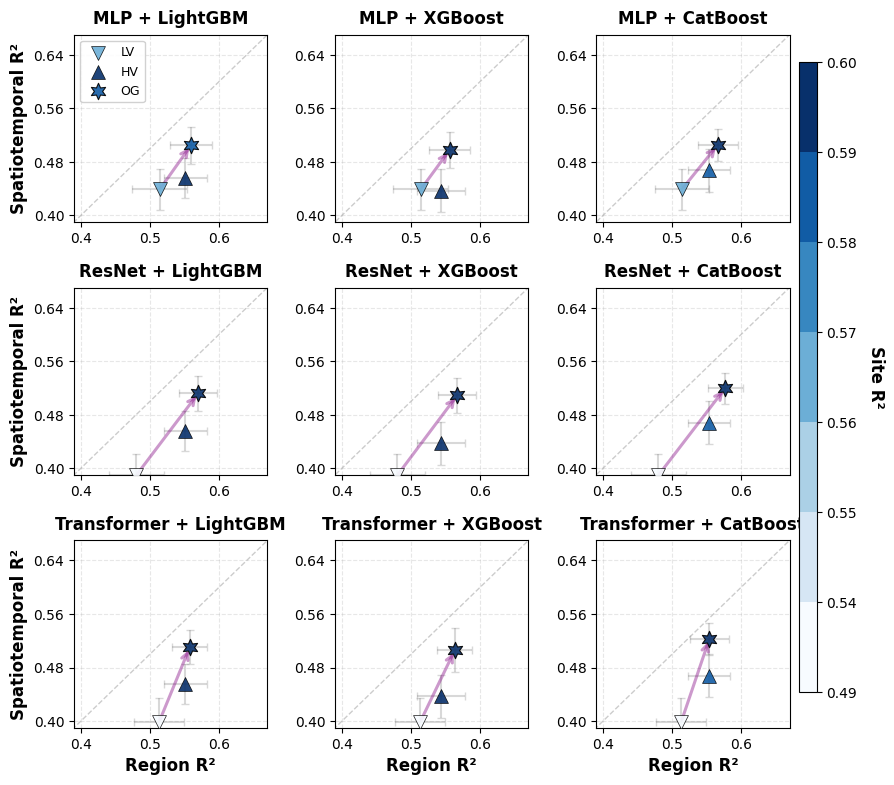

✓ Loaded color metric: Site
✓ Loaded results for 18 models
  Available models: ['bigcatboost', 'biglightgbm', 'bigxgboost', 'mlp+bigcatboost', 'mlp+biglightgbm']...
✓ Using non-uniform color scale with 8 boundaries
  Range: 0.490 - 0.600


d:\OneDrive\Code\Ozone_Reconstruction\Submission_Code\local_overfit\source_code\figure3.py:801: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Figure saved to: Figure/FS18_2020.jpg


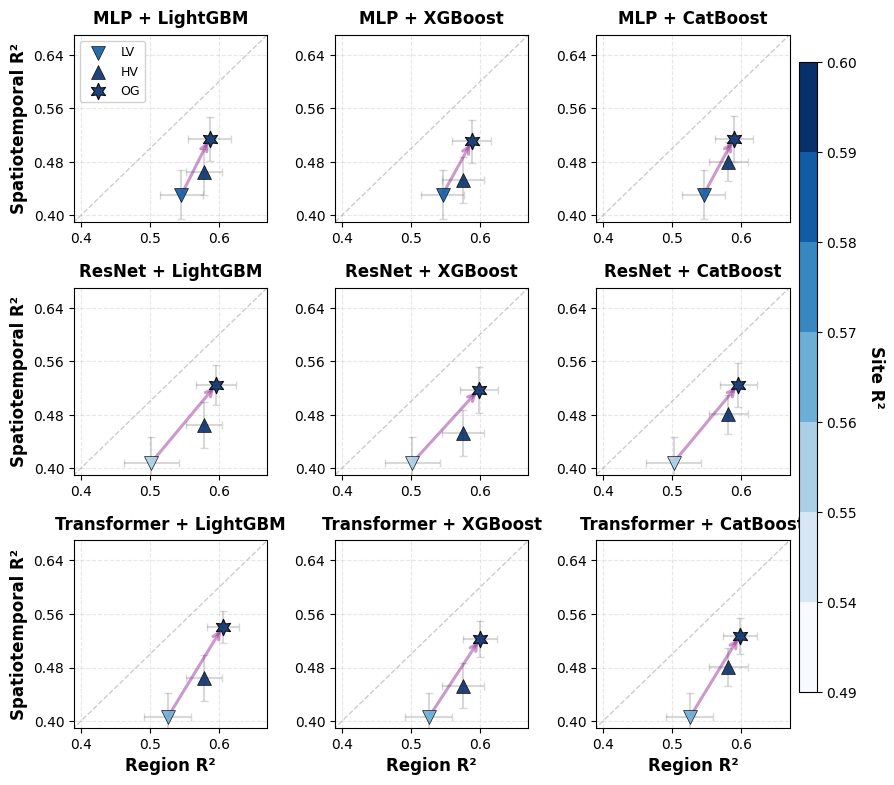

✓ Loaded color metric: Site
✓ Loaded results for 18 models
  Available models: ['bigcatboost', 'biglightgbm', 'bigxgboost', 'mlp+bigcatboost', 'mlp+biglightgbm']...
✓ Using non-uniform color scale with 8 boundaries
  Range: 0.490 - 0.600


d:\OneDrive\Code\Ozone_Reconstruction\Submission_Code\local_overfit\source_code\figure3.py:801: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Figure saved to: Figure/FS18_2021.jpg


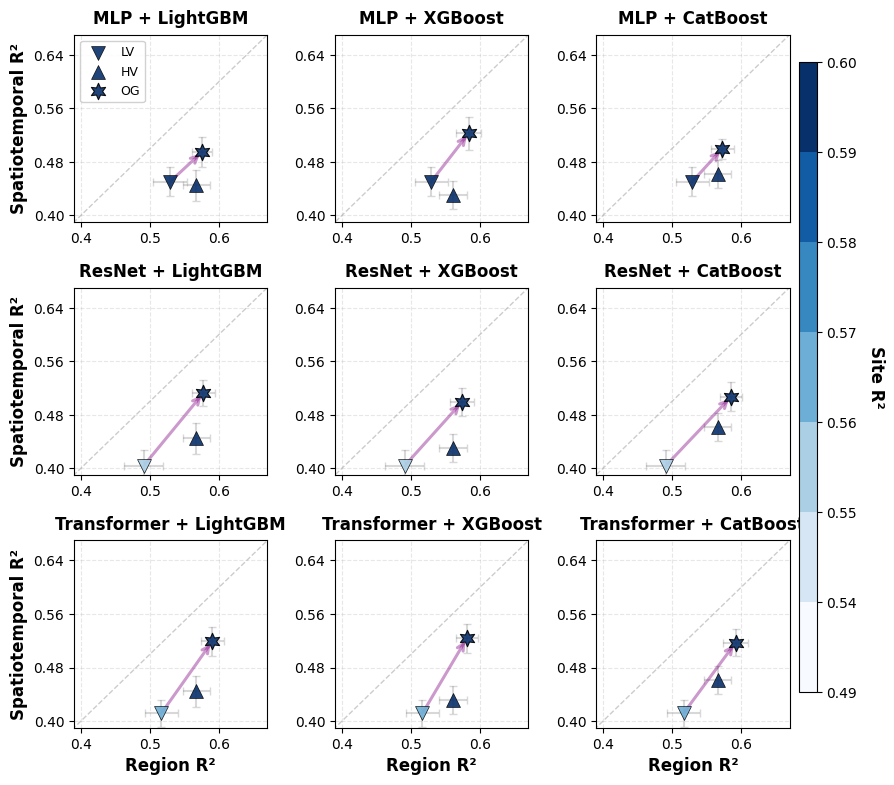

In [2]:
# ============================================================
# Figure 3: OG Ablation Study (3×3 Grid)
# ============================================================
# Compare DL models (MLP, ResNet, Transformer) × ML models (LightGBM, XGBoost, CatBoost)
# Original call from 4. All_Figures.ipynb

from source_code.figure3 import plot_og_ablation
from matplotlib.colors import LinearSegmentedColormap

# 
custom_cmap = LinearSegmentedColormap.from_list(
    'custom', ['grey', 'lightblue']
)

for year in [2019,2020,2021]:

    # 输入参数 (exactly as in original 4. All_Figures.ipynb)
    project_path = f"{DATA_DIR}/appendix/10-Fold_{year}"
    dl_group = ['mlp', 'resnet', 'transformer']
    ml_group = ['biglightgbm', 'bigxgboost', 'bigcatboost']
    metrics = ["Grid", "Spatiotemporal_block"]

    # 
    fig, axes = plot_og_ablation(
        project_path=project_path,
        dl_group=dl_group,
        ml_group=ml_group,
        metrics=metrics,
        x_lim=[0.39, 0.67],
        y_lim=[0.39, 0.67],
        #mode="percent",
        early_stop=True,
        early_type="train",
        x_locator=3, 
        y_locator=4, 
        figsize=(9, 9),
        color_metric="Site",
        show_ensemble_og=False,
        show_ensemble_mldl=False,
        show_ensemble_ogmls=False,
        show_ensemble_dlmls=False,
        color_boundaries=[0.54, 0.55, 0.56, 0.57, 0.49, 0.58, 0.59, 0.60],
        bold=True,
        save_path=f"{FIGURE_DIR}/FS18_{year}.jpg"
    )
    plt.show()


## OG + Baseline Detail Table

Loaded timing cache from D:\OneDrive\Code\Ozone_Reconstruction\data\training\benchmark_timing.json
  MLP:      2.86 s/epoch  ->  200 ep = 571.3 s
  MLP inference:      0.03 s
  CatBoost train:     4.31 s  (0.8% of MLP)
  CatBoost inference: 0.04 s

Relative costs (MLP = 1.0x):
  MLP                       1.00x
  CatBoost                  0.01x
  OG                        1.02x
  Vanilla KD                1.01x
  Born Again                2.00x
  Self-Training             3.00x
  Data-Free KD              1.01x
  SMOTE-R                   1.20x
  Ensemble (DLs)            3.00x
  Ensemble (MLs)            0.02x
  Ensemble (DLs+MLs)        3.02x
  Ensemble (DLs+MLs+OG)     4.05x
  Ensemble (DL+ML)          1.01x
  Ensemble (ML+OG)          1.03x
  Ensemble (DL+OG)          2.03x
  Ensemble (DL+ML+OG)       2.03x
  Ensemble (MLs+OG)         1.05x
  Ensemble (MLs+DL)         1.02x
  Ensemble (DL+DL)          2.00x
  Ensemble (DL+MLs+OG)      2.05x
  Ensemble (DL+ML+Vanilla KD) 2.02x
  Ense

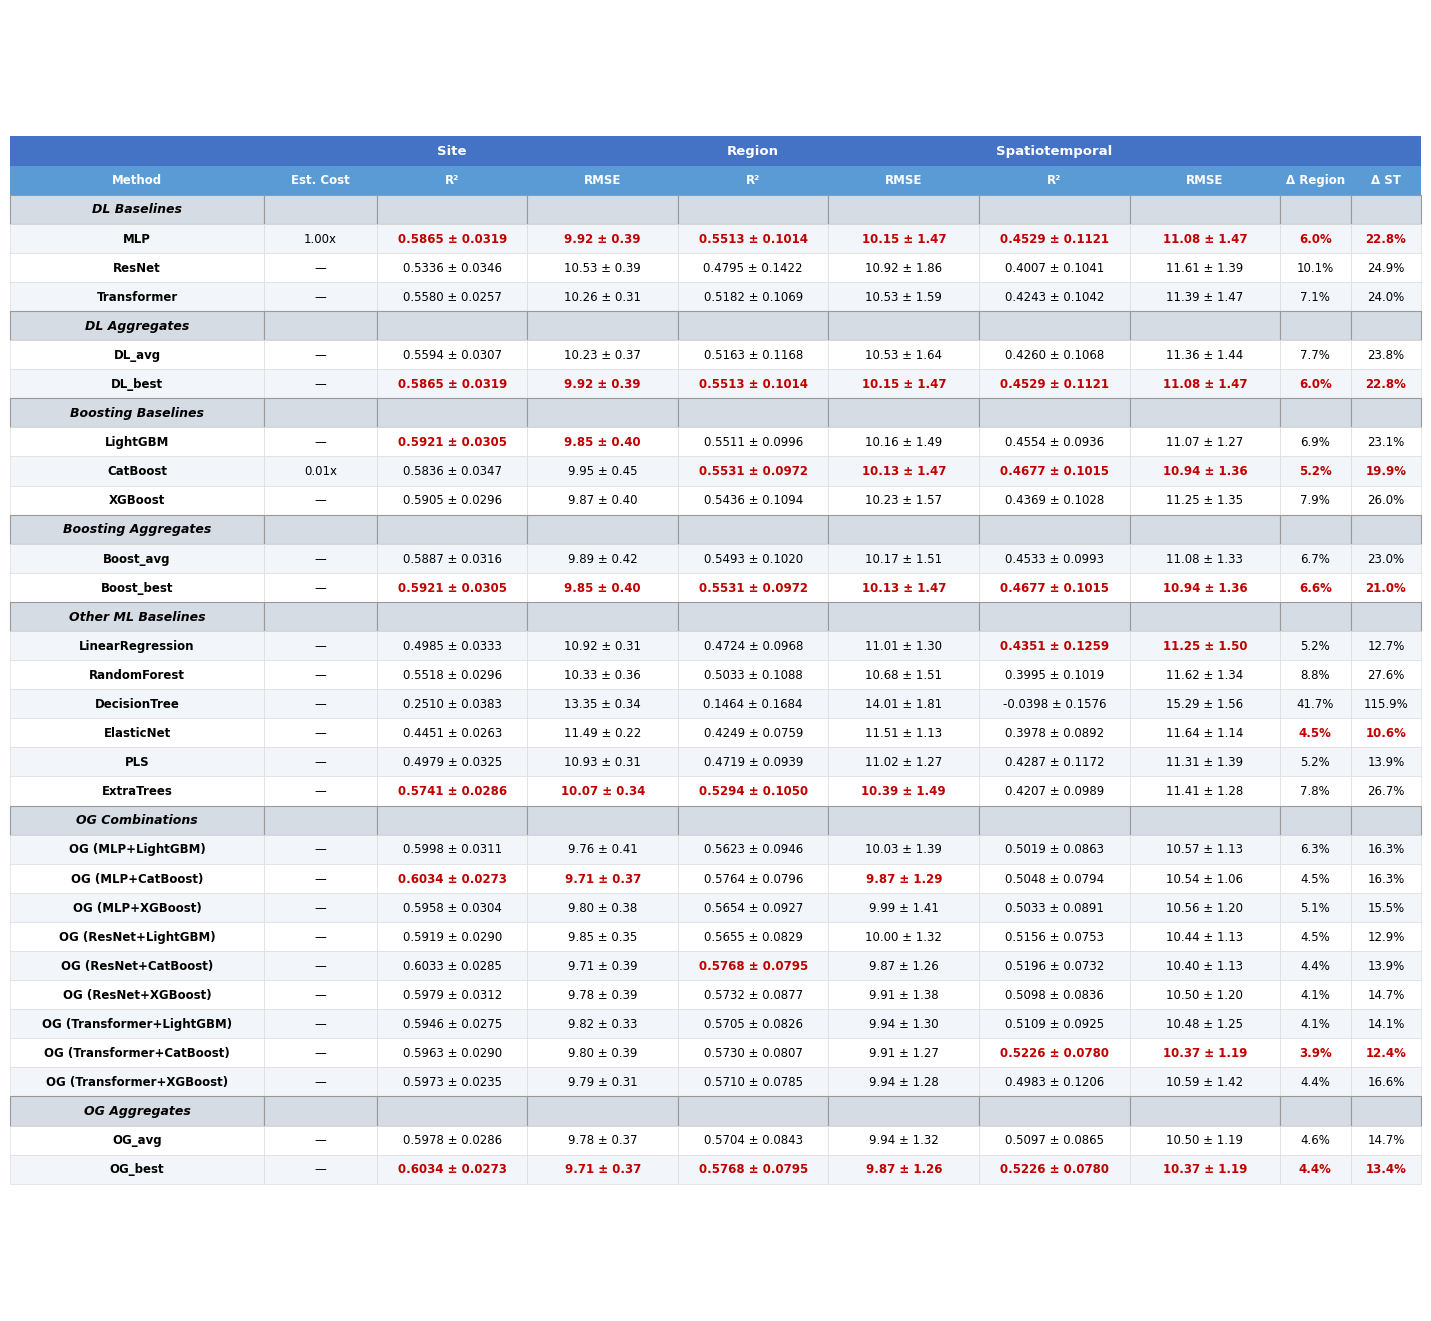

In [4]:
from source_code.apx_strategy_ab import og_baseline_table
from source_code.apx_strategy_ab import distillation_ablation_table
from source_code.apx_strategy_ab import estimate_training_cost
from source_code.apx_strategy_ab import strategy_ablation_table

cost, timing = estimate_training_cost(
    data_path=r"D:\OneDrive\Code\Ozone_Reconstruction\data\training\Site_Observation_with_feature.pkl",
    nn_epochs=200,
    load_cache=True,
)
fig_og, latex_og, raw_og = og_baseline_table(
    f"{DATA_DIR}/appendix/10-Fold-ablation",
    early_stop=True,
    cost_dict=cost,
    save_path=f"{FIGURE_DIR}/og_baseline_detail",
)



## Appendix: Ablation Distillation

In [ ]:
from source_code.utils import add_rmse_column

add_rmse_column(f"{DATA_DIR}/appendix/10-Fold-ablation", dry_run=False, verbose=True)

Loaded timing cache from D:\OneDrive\Code\Ozone_Reconstruction\data\training\benchmark_timing.json
  MLP:      2.86 s/epoch  ->  200 ep = 571.3 s
  MLP inference:      0.03 s
  CatBoost train:     4.31 s  (0.8% of MLP)
  CatBoost inference: 0.04 s

Relative costs (MLP = 1.0x):
  MLP                       1.00x
  CatBoost                  0.01x
  OG                        1.02x
  Vanilla KD                1.01x
  Born Again                2.00x
  Self-Training             3.00x
  Data-Free KD              1.01x
  SMOTE-R                   1.20x
  Ensemble (DLs)            3.00x
  Ensemble (MLs)            0.02x
  Ensemble (DLs+MLs)        3.02x
  Ensemble (DLs+MLs+OG)     4.05x
  Ensemble (DL+ML)          1.01x
  Ensemble (ML+OG)          1.03x
  Ensemble (DL+OG)          2.03x
  Ensemble (DL+ML+OG)       2.03x
  Ensemble (MLs+OG)         1.05x
  Ensemble (MLs+DL)         1.02x
  Ensemble (DL+DL)          2.00x
  Ensemble (DL+MLs+OG)      2.05x
  Ensemble (DL+ML+Vanilla KD) 2.02x
  Ense

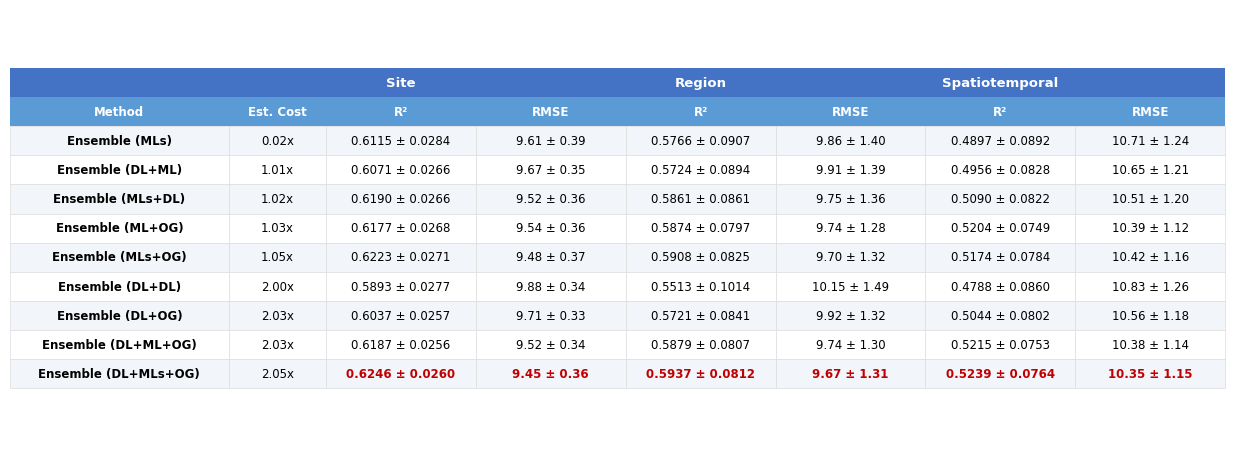

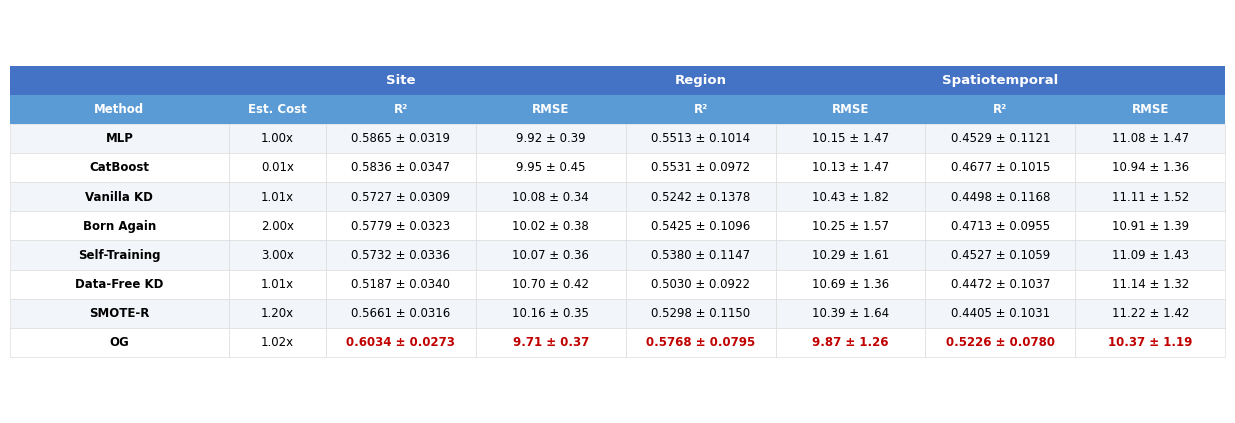

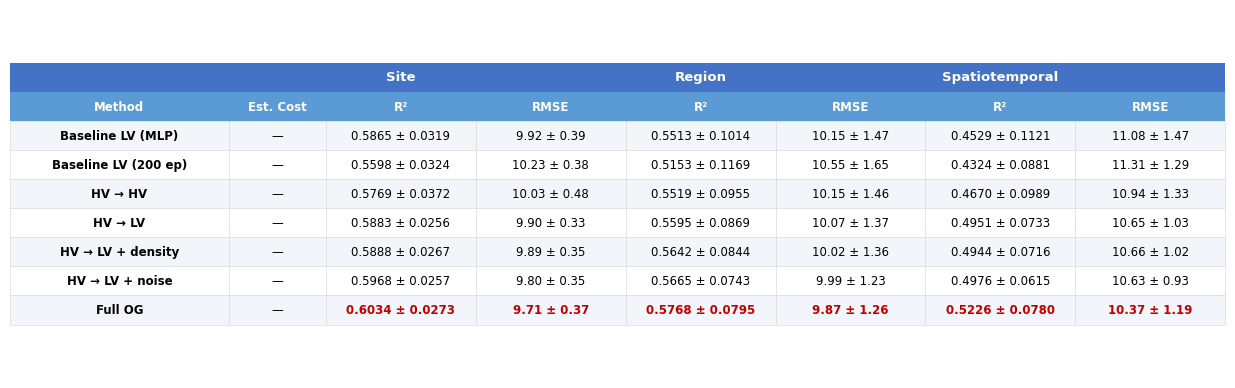

In [4]:
from source_code.apx_strategy_ab import distillation_ablation_table
from source_code.apx_strategy_ab import estimate_training_cost
from source_code.apx_strategy_ab import strategy_ablation_table
from source_code.apx_strategy_ab import OG_ablation_table

cost, timing = estimate_training_cost(
    data_path=r"D:\OneDrive\Code\Ozone_Reconstruction\data\training\Site_Observation_with_feature.pkl",
    nn_epochs=200,
    load_cache=True,
)

EARLY_STOP = 1

fig_strat, latex_strat, raw_strat = strategy_ablation_table(
    f"{DATA_DIR}/appendix/10-Fold-ablation",
    early_stop=EARLY_STOP,
    cost_dict=cost,
    save_path=f"{FIGURE_DIR}/ablation_ensemble"
)

fig_dist, latex_dist, raw_dist = distillation_ablation_table(
    f"{DATA_DIR}/appendix/10-Fold-ablation",
    cost_dict=cost,
    early_stop=EARLY_STOP,
    save_path=f"{FIGURE_DIR}/ablation_distillation"
)



Loaded timing cache from D:\OneDrive\Code\Ozone_Reconstruction\data\training\benchmark_timing.json
  MLP:      2.86 s/epoch  ->  200 ep = 571.3 s
  MLP inference:      0.03 s
  CatBoost train:     4.31 s  (0.8% of MLP)
  CatBoost inference: 0.04 s

Relative costs (MLP = 1.0x):
  MLP                       1.00x
  CatBoost                  0.01x
  OG                        1.02x
  Vanilla KD                1.01x
  Born Again                2.00x
  Self-Training             3.00x
  Data-Free KD              1.01x
  SMOTE-R                   1.20x
  Ensemble (DLs)            3.00x
  Ensemble (MLs)            0.02x
  Ensemble (DLs+MLs)        3.02x
  Ensemble (DLs+MLs+OG)     4.05x
  Ensemble (DL+ML)          1.01x
  Ensemble (ML+OG)          1.03x
  Ensemble (DL+OG)          2.03x
  Ensemble (DL+ML+OG)       2.03x
  Ensemble (MLs+OG)         1.05x
  Ensemble (MLs+DL)         1.02x
  Ensemble (DL+DL)          2.00x
  Ensemble (DL+MLs+OG)      2.05x
  Ensemble (DL+ML+Vanilla KD) 2.02x
  Ense

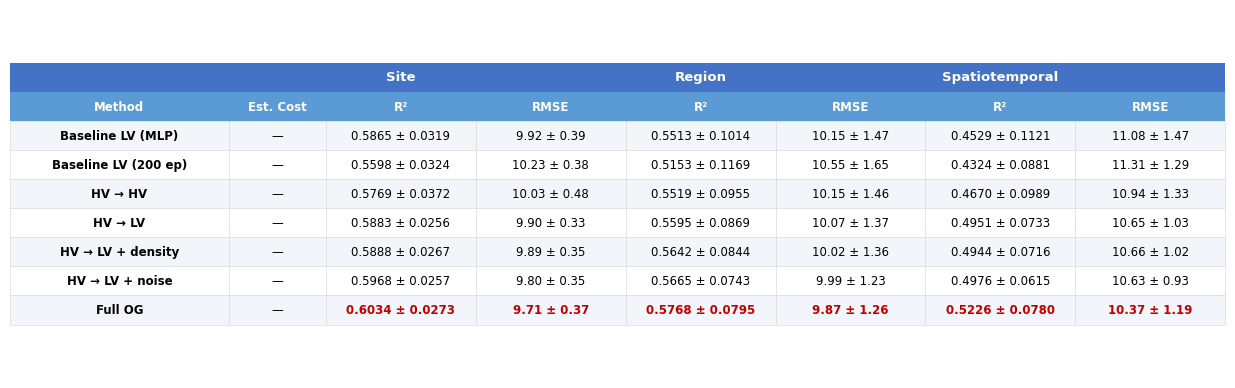

In [5]:
from source_code.apx_strategy_ab import distillation_ablation_table
from source_code.apx_strategy_ab import estimate_training_cost
from source_code.apx_strategy_ab import strategy_ablation_table

cost, timing = estimate_training_cost(
    data_path=r"D:\OneDrive\Code\Ozone_Reconstruction\data\training\Site_Observation_with_feature.pkl",
    nn_epochs=200,
    load_cache=True,
)

fig_og, latex_og, raw_og = OG_ablation_table(
    f"{DATA_DIR}/appendix/10-Fold-ablation",
    cost_dict=cost,
    early_stop=EARLY_STOP,
    save_path=f"{FIGURE_DIR}/ablation_og"
)



## Appendix: Static Performance Gaps

Full ML/DL family results (12 models) across 5 validation strategies.


In [20]:
from source_code.apx_strategy_ab import load_strategy_summary
import pandas as pd
import numpy as np

project_path = f"{DATA_DIR}/appendix/10-Fold-ablation"

ml_models = ["biglightgbm", "bigcatboost", "bigxgboost"]
dl_models = ["mlp_tearly", "resnet_tearly", "transformer_tearly"]
og_models = [
    "mlp+biglightgbm", "mlp+bigcatboost", "mlp+bigxgboost",
    "resnet+biglightgbm", "resnet+bigcatboost", "resnet+bigxgboost",
    "transformer+biglightgbm", "transformer+bigcatboost", "transformer+bigxgboost",
]

strategies = ["Site", "Grid", "Spatiotemporal_block"]

def group_avg(models, label):
    df = load_strategy_summary(project_path, models, strategies, early_stop=False)
    if df.empty:
        return []
    rows = []
    for strat in strategies:
        sub = df[df["strategy"] == strat]
        rows.append({
            "Group": label,
            "Strategy": strat,
            "R2_mean": sub["r2_mean"].mean(),
            "R2_std": sub["r2_mean"].std(),
            "RMSE_mean": sub["rmse_mean"].mean(),
            "RMSE_std": sub["rmse_mean"].std(),
            "n_models": len(sub),
        })
    return rows

rows = group_avg(ml_models, "ML (avg)") + group_avg(dl_models, "DL (avg)") + group_avg(og_models, "OG (avg)")
summary = pd.DataFrame(rows)

pivot = summary.pivot(index="Group", columns="Strategy", values=["R2_mean", "R2_std"])
pivot = pivot.reindex(["ML (avg)", "DL (avg)", "OG (avg)"])

for strat in strategies:
    pivot[("display", strat)] = pivot[("R2_mean", strat)].map(lambda x: f"{x:.3f}") + " ± " + pivot[("R2_std", strat)].map(lambda x: f"{x:.3f}")

display_df = pivot["display"][strategies]
display_df.columns = ["Site-wise", "Region-wise", "Spatiotemporal"]
print(display_df.to_string())
print("\n--- Raw values ---")
print(summary.to_string(index=False))

# OG vs DL: per-pair improvement on Spatiotemporal R²
dl_base = ["mlp", "resnet", "transformer"]
ml_base = ["biglightgbm", "bigcatboost", "bigxgboost"]

print("\n\n=== OG vs DL baseline: Spatiotemporal R² improvement ===")
pairs = []
for dl in dl_base:
    dl_df = load_strategy_summary(project_path, [dl], ["Spatiotemporal_block"], early_stop=False)
    if dl_df.empty:
        continue
    dl_r2 = dl_df["r2_mean"].values[0]
    for ml in ml_base:
        og_name = f"{dl}+{ml}"
        og_df = load_strategy_summary(project_path, [og_name], ["Spatiotemporal_block"], early_stop=False)
        if og_df.empty:
            continue
        og_r2 = og_df["r2_mean"].values[0]
        pct = (og_r2 - dl_r2) / dl_r2 * 100
        pairs.append({"DL": dl, "ML": ml, "OG": og_name, "DL_R2": dl_r2, "OG_R2": og_r2, "Δ%": pct})
        print(f"  {og_name:35s}  DL={dl_r2:.3f}  OG={og_r2:.3f}  Δ={pct:+.1f}%")

pairs_df = pd.DataFrame(pairs)
print(f"\n  Min improvement: {pairs_df['Δ%'].min():.1f}%  ({pairs_df.loc[pairs_df['Δ%'].idxmin(), 'OG']})")
print(f"  Max improvement: {pairs_df['Δ%'].max():.1f}%  ({pairs_df.loc[pairs_df['Δ%'].idxmax(), 'OG']})")
print(f"  Mean improvement: {pairs_df['Δ%'].mean():.1f}%")

              Site-wise    Region-wise Spatiotemporal
Group                                                
ML (avg)  0.589 ± 0.004  0.549 ± 0.005  0.453 ± 0.016
DL (avg)    0.586 ± nan    0.551 ± nan    0.453 ± nan
OG (avg)  0.598 ± 0.004  0.570 ± 0.005  0.510 ± 0.008

--- Raw values ---
   Group             Strategy  R2_mean   R2_std  RMSE_mean  RMSE_std  n_models
ML (avg)                 Site 0.588732 0.004497   9.890016  0.052860         3
ML (avg)                 Grid 0.549268 0.004989  10.173791  0.051581         3
ML (avg) Spatiotemporal_block 0.453337 0.015501  11.084004  0.156930         3
DL (avg)                 Site 0.586475      NaN   9.916268       NaN         1
DL (avg)                 Grid 0.551319      NaN  10.151113       NaN         1
DL (avg) Spatiotemporal_block 0.452943      NaN  11.076671       NaN         1
OG (avg)                 Site 0.597802 0.003823   9.780774  0.046186         9
OG (avg)                 Grid 0.570449 0.005089   9.940467  0.056364         9

## Appendix: Local Overfit Statistics

In [21]:
from source_code.apx_statistics_local import full_local_overfit_report

complexity_path = f"{DATA_DIR}/appendix/5CV_validation_vs_parameter"
epoch_path = f"{DATA_DIR}/appendix/5-Fold-nn_grid/epoch_analysis"

report = full_local_overfit_report(
    complexity_path=complexity_path,
    epoch_path=epoch_path,
    baseline_models=["mlp", "resnet", "transformer", "lightgbm", "catboost", "xgboost"],
    og_models=["og_mlp", "og_resnet", "og_transformer"],
    strategies=["Sample", "Site", "Grid"],
)

print("\n\nFull table:")
print(report.to_string(index=False))

LOCAL OVERFITTING SACRIFICE REPORT

────────────────────────────────────────
  COMPLEXITY DIMENSION
────────────────────────────────────────

  [Baseline models]
    mlp                   max sacrifice: Time-wise→Site-wise  R²=0.575→0.572  loss=0.6%
    resnet                max sacrifice: Region-wise→Site-wise  R²=0.571→0.567  loss=0.7%
    transformer           max sacrifice: Time-wise→Region-wise  R²=0.553→0.542  loss=2.1%
    lightgbm              max sacrifice: Region-wise→Time-wise  R²=0.731→0.670  loss=8.3%
    catboost              max sacrifice: Region-wise→Time-wise  R²=0.730→0.610  loss=16.4%
    xgboost               max sacrifice: Site-wise→Region-wise  R²=0.561→0.524  loss=6.5%

  [OG models]
    og_mlp                max sacrifice: Time-wise→Site-wise  R²=0.584→0.570  loss=2.5%
    og_resnet             max sacrifice: Region-wise→Time-wise  R²=0.615→0.605  loss=1.6%
    og_transformer        max sacrifice: Region-wise→Site-wise  R²=0.582→0.568  loss=2.3%

───────────────

In [ ]:
# TODO: Static performance gaps figures


## Appendix: Dynamic Performance Analysis

Training dynamics across all OG model combinations.


In [ ]:
# TODO: Dynamic performance figures


## Appendix: Accuracy Surface Evaluation

Comparison of interpolation methods vs. proposed GAM+SVM framework.

In [7]:
# TODO: Accuracy surface evaluation figures


## Appendix: Additional Datasets

Generalization testing on additional datasets beyond TOAR.


In [ ]:
# TODO: Additional datasets figures


## Appendix: Thematic Groupings

Performance analysis across urbanization, emission, and vegetation regimes.


In [ ]:
# TODO: Thematic grouping figures
